In [97]:
import numpy as np

In [98]:
# training data
X_raw = np.linspace(-2*np.pi, 2*np.pi, 5000)
Y = np.sin(X_raw)          
X = X_raw / (2*np.pi)      
Y = Y                      

In [99]:
X.shape

(5000,)

In [100]:
X = X.reshape(-1, 1)
Y = Y.reshape(-1, 1)
X.shape

(5000, 1)

In [101]:
X = X.T
Y = Y.T
X.shape

(1, 5000)

In [102]:
class Layer_Dense:
    def __init__(self,inputs,neurons):
        self.weights = np.random.randn(neurons,inputs)*np.sqrt(1 / inputs)
        self.biases = np.zeros((neurons,1))
    def forward(self,x):
        self.inputs = x
        self.output = self.weights @ x + self.biases
        return self.output
class TanhActivation:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.tanh(inputs)
        return self.output
class LossFunction:
    def forward(self,y_pred,y_true):
        self.loss = np.mean((y_true - y_pred) ** 2)
        return self.loss

In [103]:
layer_1 = Layer_Dense(1,64)
layer_2 = Layer_Dense(64,32)
layer_3 = Layer_Dense(32,1)

tanh_1 = TanhActivation()
tanh_2 = TanhActivation()

loss_func = LossFunction()

In [107]:
learning_rate = 0.05
epochs = 1000

best_parameters = {
    "w1":0,
    "b1":0,
    "w2":0,
    "b2":0,
    "w3":0,
    "b3":0
}

best_epoch = 0
best_loss = np.inf
best_epoch = 0

for epoch in range(epochs):
    #initiallization
    output1 = tanh_1.forward(layer_1.forward(X))
    output2 = tanh_2.forward(layer_2.forward(output1)) 
    predictions = layer_3.forward(output2)

    loss = loss_func.forward(predictions,Y)
    mae = np.mean(np.abs(predictions - Y))

    m = X.shape[1]

    dz3 = 2 *(predictions - Y)
    dw3 = (1/m) * (dz3 @ output2.T)
    db3 = (1/m) * np.sum(dz3,axis=1,keepdims=True)
    da2 = layer_3.weights.T @ dz3

    dz2 = da2.copy()
    dz2 = da2 * (1 - output2**2)
    dw2 = (1/m) * (dz2 @ output1.T)
    db2 = (1/m) * np.sum(dz2,axis=1,keepdims=True)
    da1 = layer_2.weights.T @ dz2

    dz1 = da1.copy()
    dz1 = da1 * (1 - output1**2)
    dw1 = (1/m) * (dz1 @ X.T)
    db1 = (1/m) * np.sum(dz1,axis=1,keepdims=True)

    layer_1.weights -= learning_rate * dw1
    layer_1.biases  -= learning_rate * db1

    layer_2.weights -= learning_rate * dw2
    layer_2.biases  -= learning_rate * db2

    layer_3.weights -= learning_rate * dw3
    layer_3.biases  -= learning_rate * db3

    ss_res = np.sum((Y - predictions) ** 2)
    ss_tot = np.sum((Y - np.mean(Y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    if epoch%100==0:
        print(f"Epoch {epoch:5d} | Loss: {loss:.8f} | R²: {r2:.4f}")
    

    if loss < best_loss:
        best_loss = loss
        best_epoch = epoch

        best_parameters["w1"] = layer_1.weights.copy()
        best_parameters["b1"] = layer_1.biases.copy()

        best_parameters["w2"] = layer_2.weights.copy()
        best_parameters["b2"] = layer_2.biases.copy()

        best_parameters["w3"] = layer_3.weights.copy()
        best_parameters["b3"] = layer_3.biases.copy()
    

Epoch     0 | Loss: 0.09686886 | R²: 0.8062
Epoch   100 | Loss: 0.08986383 | R²: 0.8202
Epoch   200 | Loss: 0.08708011 | R²: 0.8258
Epoch   300 | Loss: 0.08499190 | R²: 0.8300
Epoch   400 | Loss: 0.08306963 | R²: 0.8338
Epoch   500 | Loss: 0.08119017 | R²: 0.8376
Epoch   600 | Loss: 0.07930350 | R²: 0.8414
Epoch   700 | Loss: 0.07737792 | R²: 0.8452
Epoch   800 | Loss: 0.07538255 | R²: 0.8492
Epoch   900 | Loss: 0.07328094 | R²: 0.8534


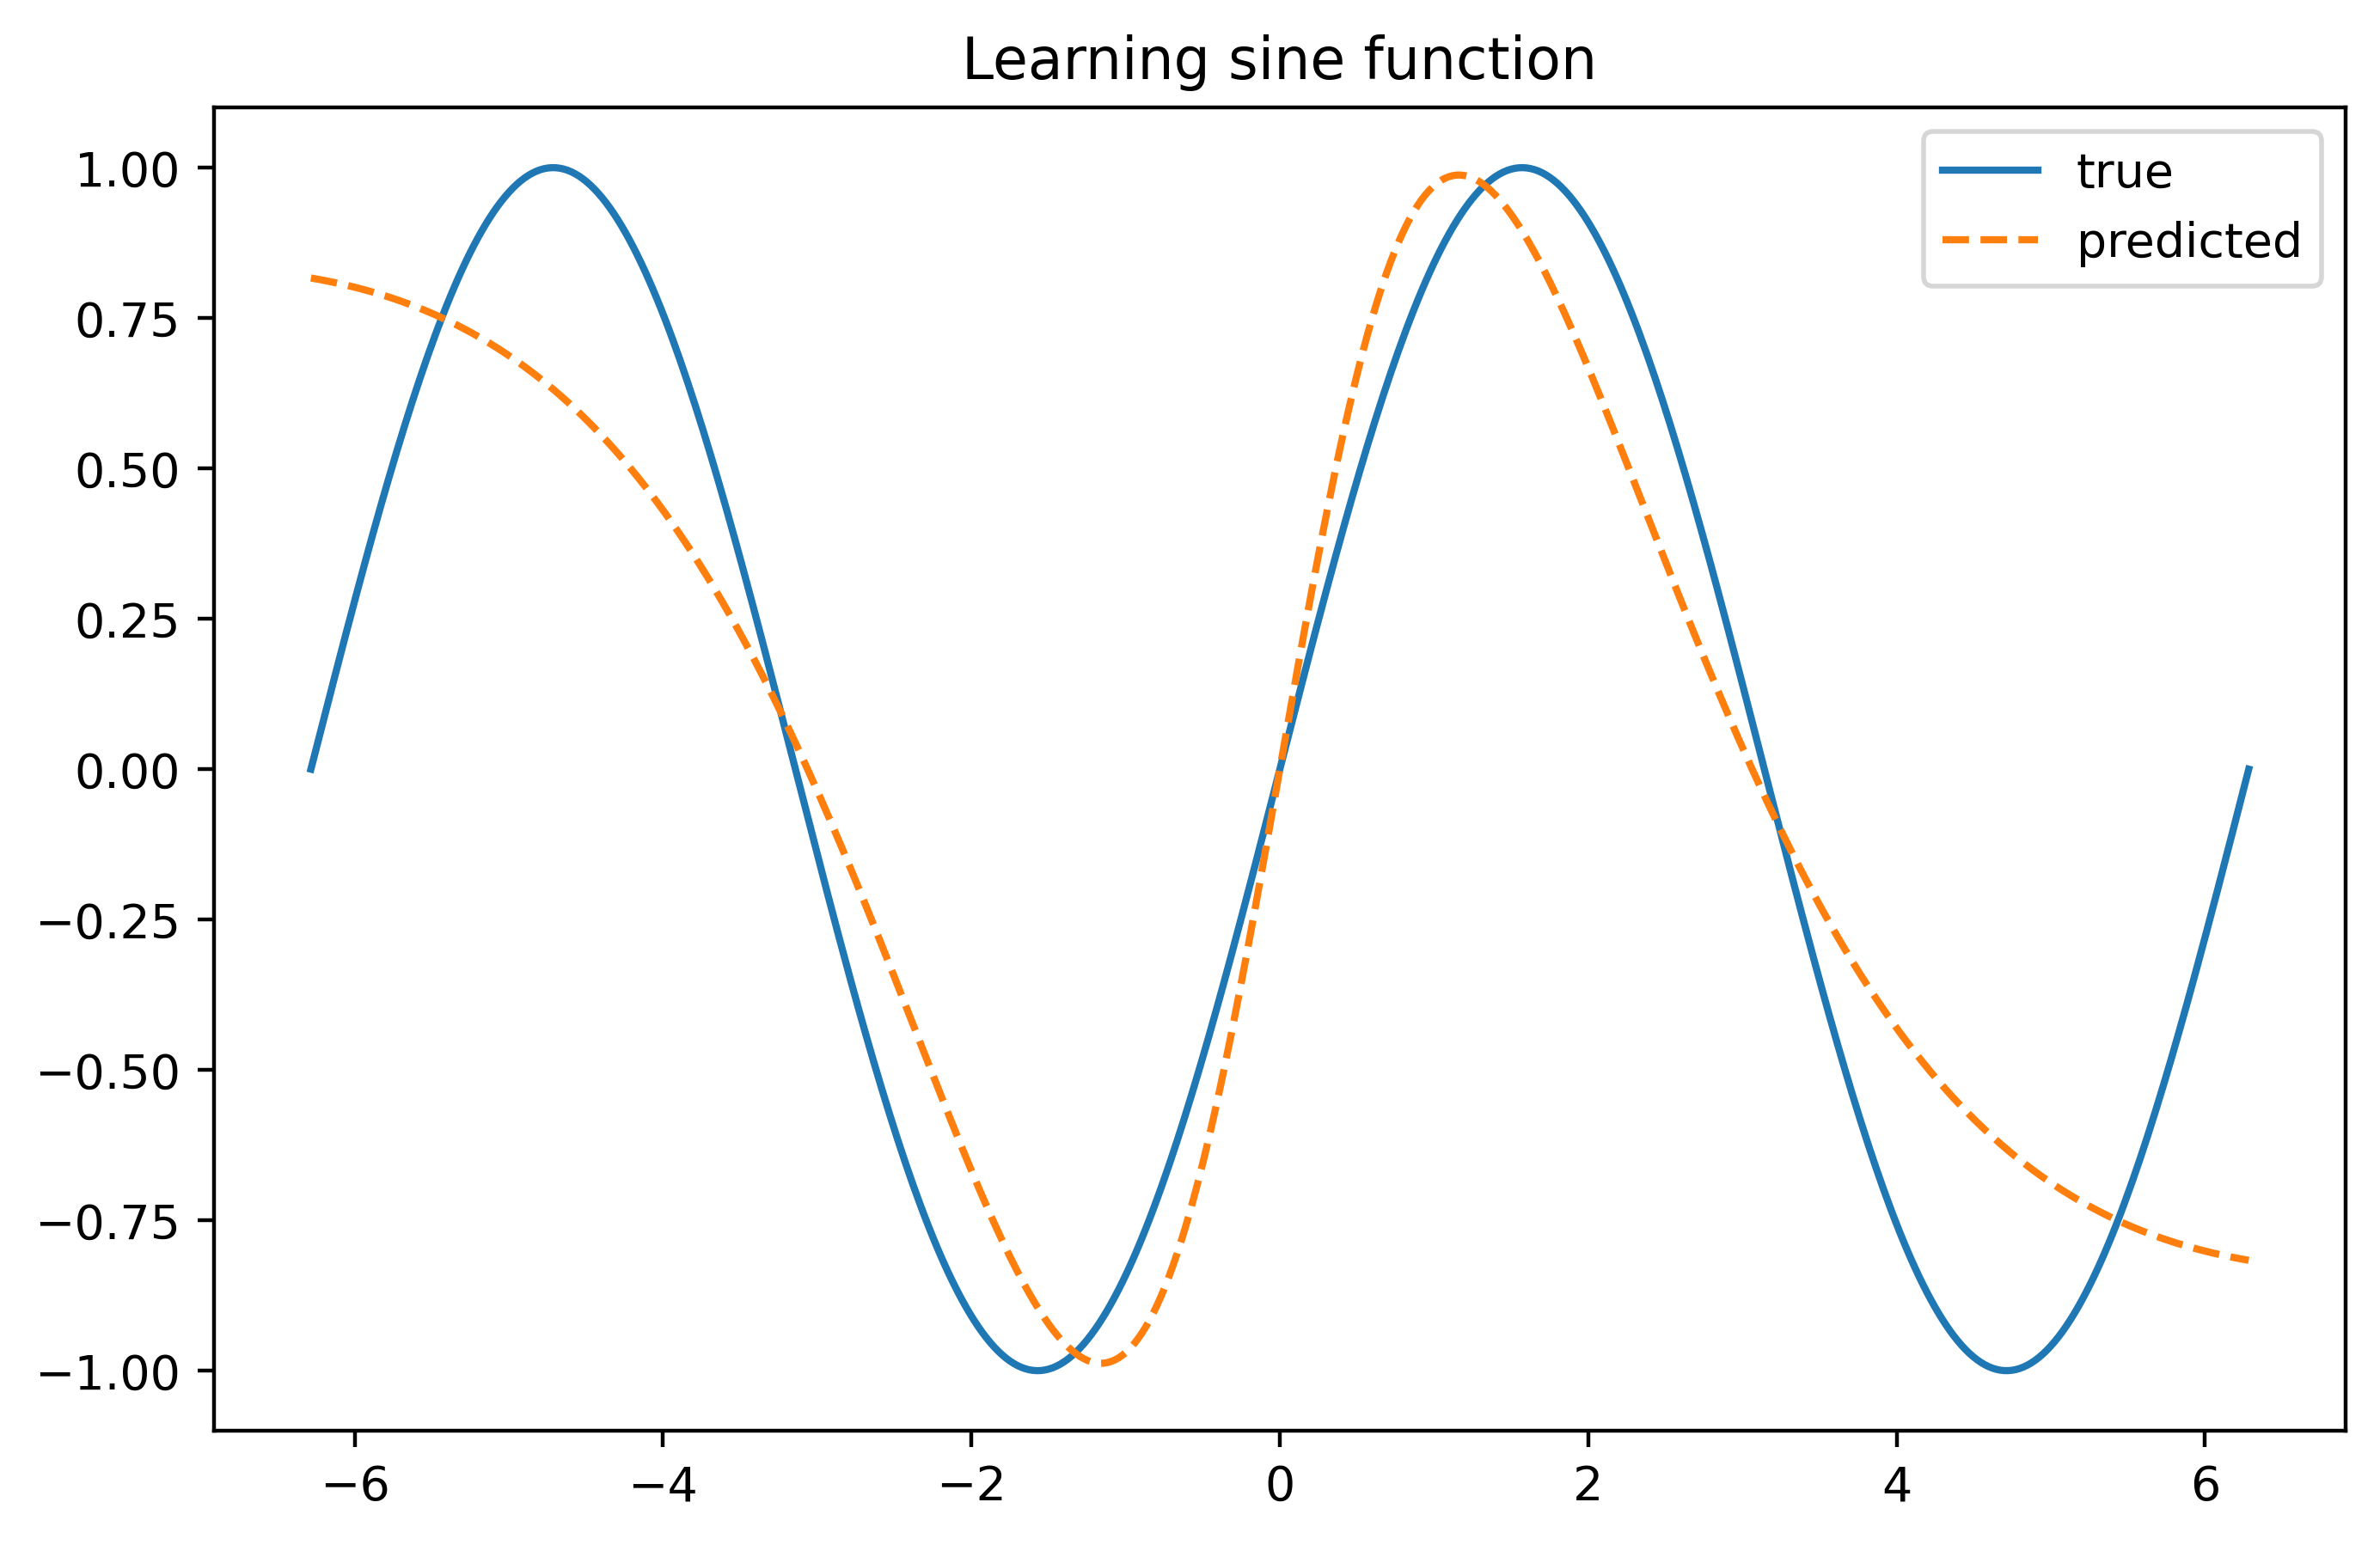

In [110]:
import matplotlib.pyplot as plt

x_plot_raw = np.linspace(-2*np.pi, 2*np.pi, 500)
x_plot = (x_plot_raw / (2*np.pi)).reshape(1, -1)

o1 = np.tanh(best_parameters["w1"] @ x_plot + best_parameters["b1"])
o2 = np.tanh(best_parameters["w2"] @ o1     + best_parameters["b2"])
y_hat = best_parameters["w3"] @ o2          + best_parameters["b3"]

plt.figure(figsize=(8,5),dpi=400)
plt.plot(x_plot_raw, np.sin(x_plot_raw), label="true")
plt.plot(x_plot_raw, y_hat.flatten(), label="predicted", linestyle="--")
plt.title("Learning sine function")
plt.legend()
plt.show()